# Hierarchical forecasting with `numpyro_forecast`

Port of NumPyro's [hierarchical forecasting tutorial](https://num.pyro.ai/en/stable/tutorials/hierarchical_forecasting.html).
We forecast **hourly BART origin-destination ridership** with per-station
seasonality, a per-destination random-walk level, a pairwise affinity term and
additive origin/destination noise scales.

Arrays use the package convention `(origin, time, destin)` (time at axis `-2`).


In [1]:
import arviz as az
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import random

from numpyro_forecast import Forecaster, eval_crps
from numpyro_forecast.datasets import load_bart_hierarchical
from numpyro_forecast.models import HierarchicalForecaster

rng_key = random.PRNGKey(0)

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

A 90-day training window followed by a 2-week test window. For a fast, self-contained run we use the first 15 stations; the identical code runs on all 50 stations (just slower).

In [2]:
y_full, split, stations = load_bart_hierarchical(train_days=90, test_weeks=2)
n_stations = 15  # set to len(stations) for the full panel
y = y_full[:n_stations, :, :n_stations]

y_train = y[:, :split, :]
y_test = y[:, split:, :]
covariates = jnp.zeros_like(y)  # dummy covariates (model is covariate-free)
covariates_train = covariates[:, :split, :]
print("panel", y.shape, "train hours", split, "test hours", y.shape[1] - split)

panel (15, 2496, 15) train hours 2160 test hours 336


## Fit with SVI

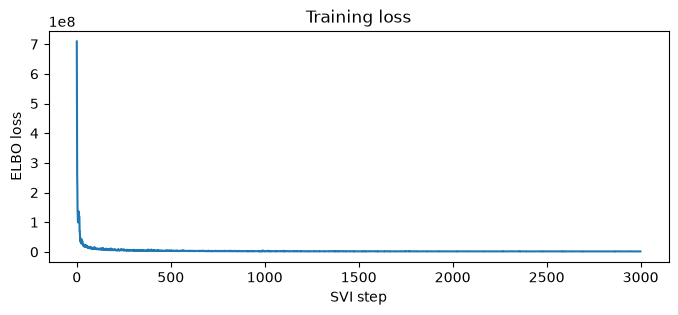

In [3]:
rng_key, key_fit = random.split(rng_key)
forecaster = Forecaster(
    HierarchicalForecaster(period=24 * 7),
    y_train,
    covariates_train,
    num_steps=3_000,
    rng_key=key_fit,
)
plt.figure(figsize=(8, 3))
plt.plot(forecaster.losses)
plt.xlabel("SVI step")
plt.ylabel("ELBO loss")
plt.title("Training loss");

## Forecast and evaluate

In [4]:
rng_key, key_fc = random.split(rng_key)
pred = forecaster(y_train, covariates, num_samples=200, rng_key=key_fc)
print("forecast shape", pred.shape)  # (sample, origin, future, destin)
print("test CRPS", round(eval_crps(pred, y_test), 4))

forecast shape (200, 15, 336, 15)
test CRPS 3.4643


## Plot a single origin-destination forecast (ArviZ >= 1.0)

Using `az.plot_lm` (the replacement for the legacy `az.plot_hdi`).

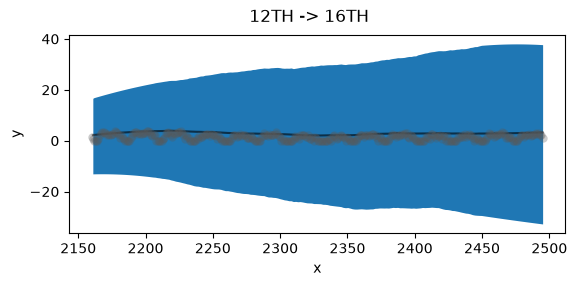

In [5]:
origin, destin = 0, 1
fc = np.asarray(pred[:, origin, :, destin])  # (sample, future)
truth = np.asarray(y_test[origin, :, destin])
time = np.arange(split, y.shape[1]).astype(float)
idata = az.from_dict(
    {
        "posterior_predictive": {"y": fc[None]},
        "observed_data": {"y": truth},
        "constant_data": {"x": time},
    },
    coords={"time": time},
    dims={"y": ["time"], "x": ["time"]},
)
az.plot_lm(idata, y="y", x="x", ci_kind="hdi", ci_prob=0.94)
plt.suptitle(f"{stations[origin]} -> {stations[destin]}");